# Seismic signals preprocessing and exploration

This notebook loads, preprocesses, and explores seismic signal time series (acceleration, velocity, or displacement). The data type is configurable via 
the DATA_TYPE parameter.

Two separate preprocessing pipelines are applied:

1. **Pipeline A (PDF analysis)**: All signals with baseline correction and normalization. Normalized data enable cross-station comparison of distribution shapes for heavy-tail assessment and statistical analysis.

2. **Pipeline B (Moment scaling analysis)**: All signals with baseline correction but **without normalization**. Physical units are preserved.

**Key difference**: Pipeline A creates both the raw signal column and its 
normalized version, while Pipeline B creates only the raw signal column in 
physical units.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import logging
from src import (
    build_signals,
    preprocess_signals,
    validate_preprocessing,
    set_plot_style,
    preprocess_checks_to_latex,
    plot_signal_length_distribution,
    plot_station_waveforms,
    plot_signals_distributions,
    plot_postcheck_pdf,
    plot_postcheck_moment_scaling)
from IPython.display import display
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

Data type selection (acceleration, velocity, or displacement) and derivation of type-specific parameters: signal column name and physical unit. Output directories for figures, processed data, and LaTeX tables are also defined.

In [2]:
# CONFIGURATION
EVENT_ID = 'IT-2009-0009'
DATA_TYPE = 'acceleration'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

In [3]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Define all paths from project root
DATA_RAW = PROJECT_ROOT / 'data' / 'raw' / EVENT_ID
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01b_signals' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '01b_signals' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(DATA_PROCESSED.exists(), f"Processed data directory ready: {DATA_PROCESSED}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/acceleration
INFO | Processed data directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01b_signals/acceleration


## 3. Data loading

Raw signal time series are extracted from the ITACA .ASC files within the corresponding zip archive. The function `build_signals` reads the signal samples and returns a long-format dataframe with 
one row per sample.

In [4]:
# Load data
logger.info(f"Loading {DATA_TYPE} data...")

# Determine zip filename based on data type
if DATA_TYPE == 'acceleration':
    zip_filename = 'query_acc.zip'
elif DATA_TYPE == 'velocity':
    zip_filename = 'query_vel.zip'
elif DATA_TYPE == 'displacement':
    zip_filename = 'query_disp.zip'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

df_signals = build_signals(DATA_RAW / zip_filename, signal_type=SIGNAL_COLUMN)
df_meta = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01a_metadata' / DATA_TYPE / f'metadata_clean_{DATA_TYPE[:3]}.parquet')

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}\n")

# Check if signals were loaded successfully
check(df_signals is not None, f"{DATA_TYPE.capitalize()} dataframe created")
check(len(df_signals) > 0, f"{DATA_TYPE.capitalize()} dataframe is not empty")
logger.info(f"{DATA_TYPE.capitalize()} dataframe loaded, shape: {df_signals.shape}\n")

INFO | Loading acceleration data...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (192, 38)

INFO | Acceleration dataframe created
INFO | Acceleration dataframe is not empty
INFO | Acceleration dataframe loaded, shape: (4136955, 3)



## 4. Exploration (raw signals)

Preliminary inspection of the raw signals: shape, column structure, signal length distribution across files, and basic amplitude statistics. Visual exploration includes waveform plots and distribution histograms.

### Signal length distribution

Distribution of recording durations across all files. Signal lengths vary due to different trigger durations and station-specific recording configurations.

INFO | Plotting signal length distribution...
INFO | N files: 192 — lengths range: 8000–62478 samples


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/signal_length_distribution_acc.pdf


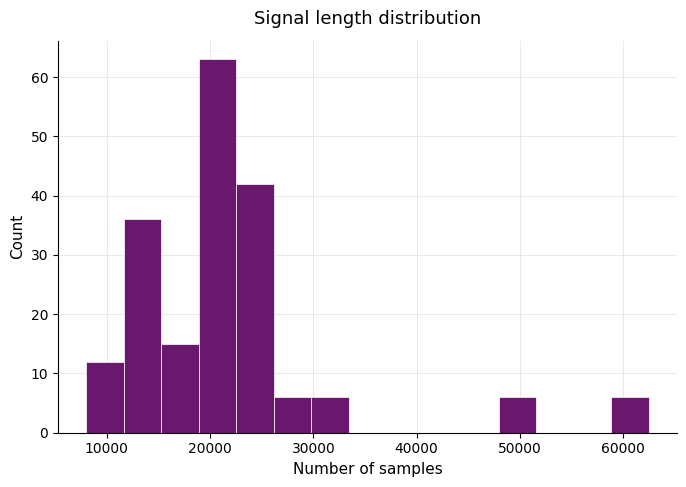

In [5]:
logger.info("Plotting signal length distribution...")
signal_lengths = df_signals.groupby('file')['sample'].max() + 1
logger.info(f"N files: {len(signal_lengths)} — lengths range: "
            f"{signal_lengths.min()}–{signal_lengths.max()} samples")
plot_signal_length_distribution(signal_lengths, output_dir=FIGURES_DIR, prefix=DATA_TYPE[:3])

### Signal distribution

The distribution of signal values is visualized on a logarithmic scale to better appreciate the heavy tails of the distribution. The dominance of near-zero values reflects the long pre-event and post-event noise windows.

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/signal_distribution_acc.pdf


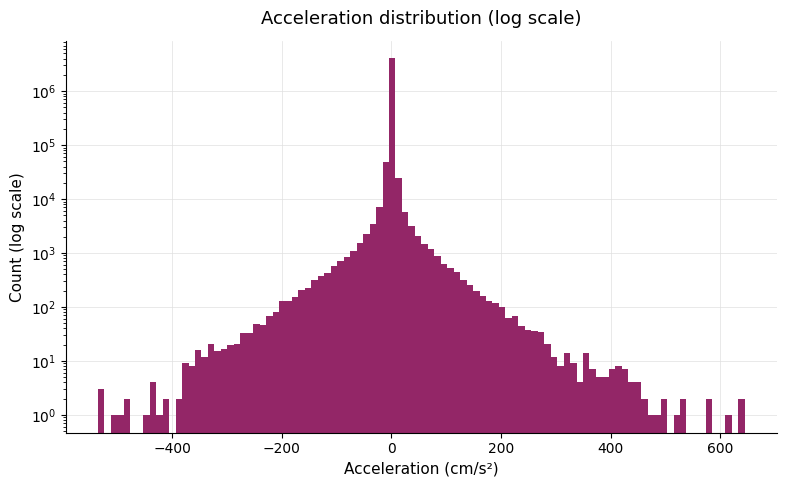

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/signal_by_component_acc.pdf


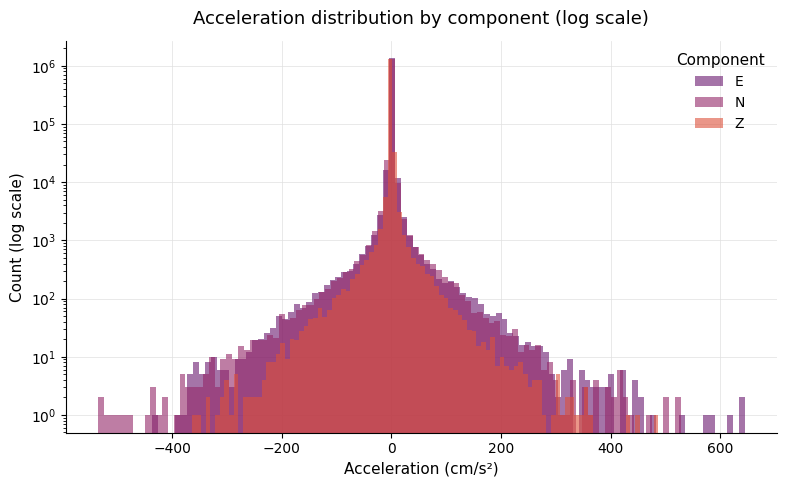

In [6]:
orientation_groups = {
    'E': ['HNE', 'HGE', 'HLE'],
    'N': ['HNN', 'HGN', 'HLN'],
    'Z': ['HNZ', 'HGZ', 'HLZ']
}

plot_signals_distributions(
    df_signals, df_meta,
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT if DATA_TYPE == 'acceleration' else DATA_TYPE.capitalize(),
    orientation_groups=orientation_groups,
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

## 5. Preprocessing for PDF analysis

The PDF analysis pipeline enables cross-station comparison of distribution shapes by normalizing signals to a common scale. The pipeline offers independent 
control over three preprocessing steps:

**Available preprocessing options:**

1. **Length filtering** (`filter_length` parameter)
   - If `True`: Retains only signals exceeding a minimum sample count. Useful when long time scales are required for analysis.
   - If `False`: Uses all available signals regardless of length. Recommended for PDF analysis to maximize statistical sample size.

2. **Baseline correction** (`baseline_correction` parameter)
   - If `True`: Removes per-signal mean to ensure zero baseline. Recommended always to eliminate systematic offsets.
   - If `False`: Keeps original baseline (not recommended).

3. **Normalization** (`normalize` parameter)
   - If `True`: Divides each signal by its standard deviation, creating an additional normalized column. Essential for PDF analysis to enable fair cross-station comparisons.
   - If `False`: Preserves physical units (not suitable for comparing signals with different amplitudes).

**Critical choice**: Normalization must be enabled for PDF analysis to remove amplitude differences and focus on distribution shape characteristics (heavy tails, asymmetry, scale invariance).

### Pipeline application

In [7]:
logger.info("Preprocessing signals — PDF analysis pipeline")
df_signals_pdf = preprocess_signals(
    df_signals,
    signal_column=SIGNAL_COLUMN,
    filter_length=False,        # Use all 66 files
    baseline_correction=True,   # Remove baseline
    normalize=True              # Normalize for PDF comparison
)

INFO | Preprocessing signals — PDF analysis pipeline


Length filtering: DISABLED (using all 192 files)
Baseline correction: max residual mean = 6.06e-16
Normalization: mean std = 1.0000000000 (expected: 1.0)


### Post-preprocessing validation and saving

Quality checks verify correct application of baseline correction and normalization. Preprocessed data are saved to parquet format for use in subsequent notebooks.

INFO | Running quality checks — PDF analysis pipeline
INFO | Baseline corrected: max residual = 6.06e-16
INFO | Normalized: mean std = 1.0000000000
INFO | No NaN in acceleration
INFO | No NaN in acceleration_normalized
INFO | No Inf in acceleration
INFO | No Inf in acceleration_normalized
INFO | All 192 files retained
INFO | All checks passed. Shape: (4136955, 4)


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/postcheck_single_acc.pdf


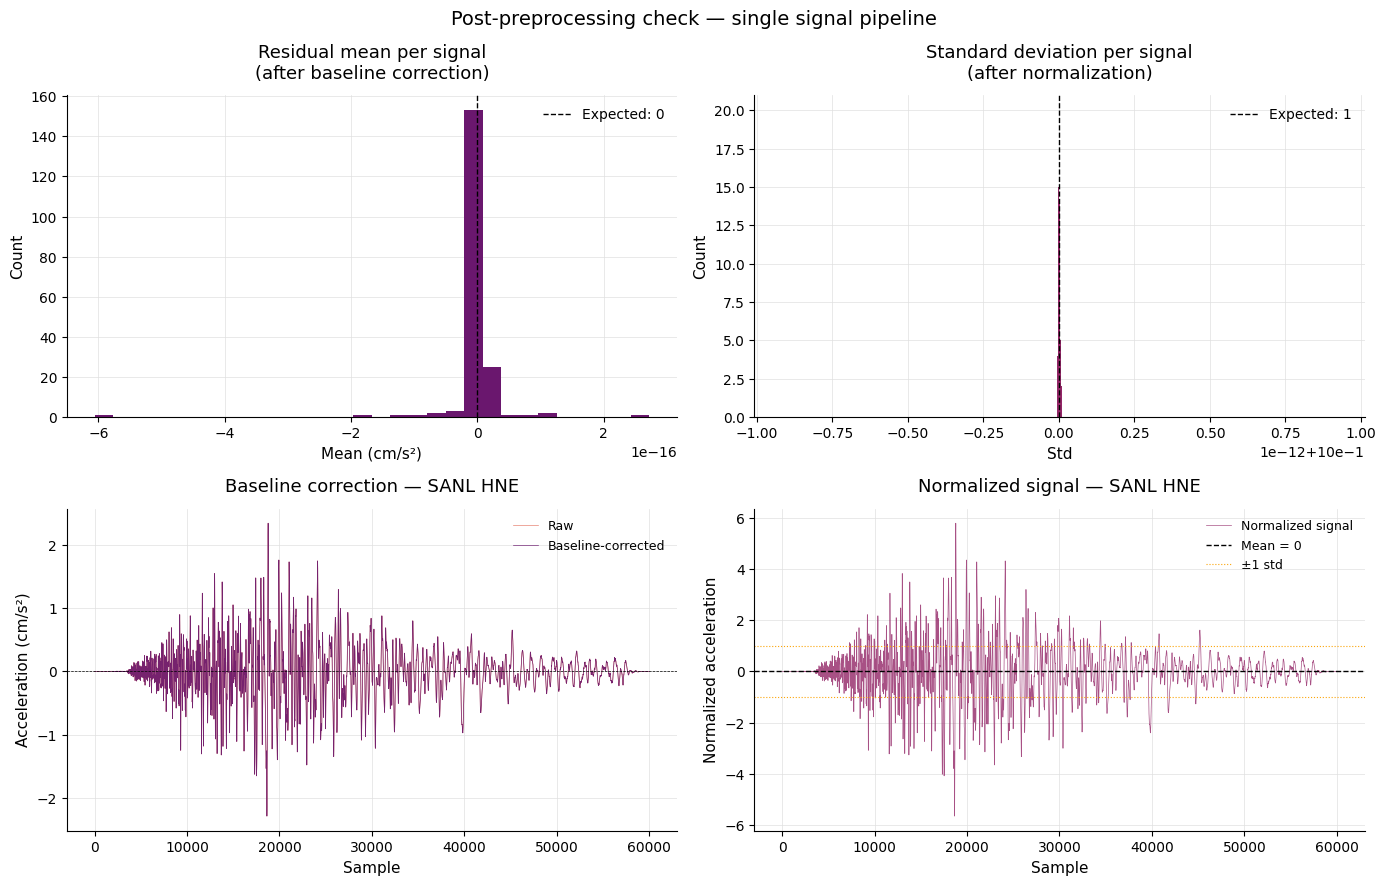

INFO | Saving preprocessed data
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01b_signals/acceleration/acc_preprocessed_pdf.parquet


In [8]:
expected_files = df_signals['file'].nunique()
validate_preprocessing(
    df_signals_pdf,
    signal_column=SIGNAL_COLUMN,
    expected_files=expected_files, 
    check_normalized=True,
    pipeline_name="PDF analysis"
)

normalized_col = f'{SIGNAL_COLUMN}_normalized'

plot_postcheck_pdf(df_signals, df_signals_pdf, signal_column=SIGNAL_COLUMN, output_dir=FIGURES_DIR, prefix=DATA_TYPE[:3])

logger.info("Saving preprocessed data")
try:
    output_path = DATA_PROCESSED / f'{DATA_TYPE[:3]}_preprocessed_pdf.parquet'
    df_signals_pdf.to_parquet(output_path, index=False)
    logger.info(f"Saved: {output_path}")
except Exception as e:
    logger.error(f"Error saving file: {e}")

### Station waveforms

Visual inspection of raw signal time series for all three components at each station. Waveforms show amplitude variability related to epicentral distance and local site effects.

In [9]:
plot_station_waveforms(
    df_signals_pdf, 
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT,
    output_dir=FIGURES_DIR / 'waveforms',
    prefix=DATA_TYPE[:3],
    normalized=True
)

Plotting 64 stations...
Saved: acc_SANL_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_TTS_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_ANT_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AQA_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AQG_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AQK_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AQV_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_ASS_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AVL_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_AVZ_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_BBN_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_BDT_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_BNE_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_BOJ_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_CAN_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_CDS_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_CER_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: acc_CHT_waveform

['/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_SANL_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_TTS_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_ANT_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_AQA_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_AQG_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/waveforms/acc_AQK_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi

## 6. Preprocessing for moment scaling analysis

The moment scaling pipeline requires preservation of physical units throughout preprocessing. The pipeline offers the same three configuration options as the 
PDF pipeline:

**Available preprocessing options:**

1. **Length filtering** (`filter_length` parameter)
   - If `True`: Retains only signals exceeding a minimum sample count. May exclude shorter near-field recordings.
   - If `False`: Uses all available signals regardless of length.

2. **Baseline correction** (`baseline_correction` parameter)
   - If `True`: Removes per-signal mean to ensure zero baseline. Recommended always.
   - If `False`: Keeps original baseline (may cause drift in integrated signals).

3. **Normalization** (`normalize` parameter)
   - If `True`: Divides each signal by its standard deviation, creating an additional normalized column. Used for PDF analysis.
   - If `False`: Preserves physical units. Required for moment scaling analysis and integration.

**Critical choice**: Normalization must be disabled for moment scaling analysis to preserve the physical units needed for scaling computations and integration.

### Pipeline application

In [10]:
logger.info("Preprocessing signals — Moment scaling pipeline")
df_signals_scaling = preprocess_signals(
    df_signals,
    signal_column=SIGNAL_COLUMN,
    filter_length=False,
    baseline_correction=True,
    normalize=False
)

INFO | Preprocessing signals — Moment scaling pipeline


Length filtering: DISABLED (using all 192 files)
Baseline correction: max residual mean = 6.06e-16
Normalization: DISABLED (physical units preserved)


### Post-preprocessing validation and saving

Quality checks verify correct application of baseline correction and confirm absence of normalization. Preprocessed data are saved to parquet format for use in subsequent notebooks.

INFO | Running quality checks — Moment scaling pipeline
INFO | Baseline corrected: max residual = 6.06e-16
INFO | Not normalized (physical units preserved)
INFO | No NaN in acceleration
INFO | No Inf in acceleration
INFO | All 192 files retained
INFO | All checks passed. Shape: (4136955, 3)


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/01b_signals/acceleration/postcheck_moment_scaling_acc.pdf


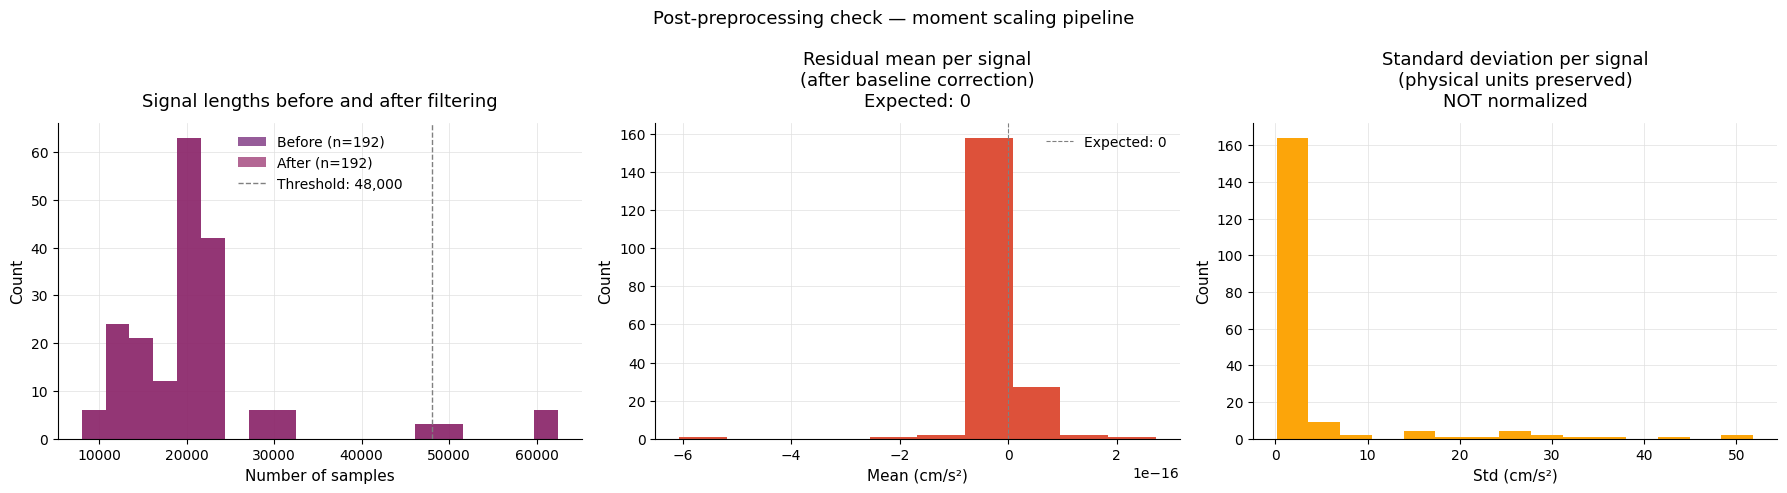

INFO | Saving preprocessed data
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01b_signals/acceleration/acc_preprocessed_scaling.parquet


In [11]:
expected_files = df_signals['file'].nunique()
validate_preprocessing(
    df_signals_scaling,
    signal_column=SIGNAL_COLUMN,
    expected_files=expected_files,
    check_normalized=False,
    pipeline_name="Moment scaling"
)

plot_postcheck_moment_scaling(
    df_signals, df_signals_scaling,
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT,
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

logger.info("Saving preprocessed data")
try:
    output_path = DATA_PROCESSED / f'{DATA_TYPE[:3]}_preprocessed_scaling.parquet'
    df_signals_scaling.to_parquet(output_path, index=False)
    logger.info(f"Saved: {output_path}")
except Exception as e:
    logger.error(f"Error saving file: {e}")

## Summary

In [12]:
# Summary table preparation
signal_lengths_raw = df_signals.groupby('file')['sample'].max() + 1
normalized_col = f'{SIGNAL_COLUMN}_normalized'

# Pipeline A (PDF) - with normalization
baseline_check_pdf = df_signals_pdf.groupby('file')[SIGNAL_COLUMN].mean()
norm_check_pdf = df_signals_pdf.groupby('file')[normalized_col].std()
bl_max_pdf = baseline_check_pdf.abs().max()
bl_pass_pdf = bl_max_pdf < 1e-10
std_mean_pdf = norm_check_pdf.mean()
std_pass_pdf = (norm_check_pdf - 1).abs().max() < 1e-6  # Logica più chiara
nan_signal_pdf = df_signals_pdf[SIGNAL_COLUMN].isna().sum()
nan_norm_pdf = df_signals_pdf[normalized_col].isna().sum()
inf_signal_pdf = np.isinf(df_signals_pdf[SIGNAL_COLUMN]).sum()
inf_norm_pdf = np.isinf(df_signals_pdf[normalized_col]).sum()
n_files_pdf = df_signals_pdf['file'].nunique()

# Pipeline B (Moment scaling) - without normalization
baseline_check_scaling = df_signals_scaling.groupby('file')[SIGNAL_COLUMN].mean()
bl_max_scaling = baseline_check_scaling.abs().max()
bl_pass_scaling = bl_max_scaling < 1e-10
nan_signal_scaling = df_signals_scaling[SIGNAL_COLUMN].isna().sum()
inf_signal_scaling = np.isinf(df_signals_scaling[SIGNAL_COLUMN]).sum()
n_files_scaling = df_signals_scaling['file'].nunique()
n_excluded = len(signal_lengths_raw) - n_files_scaling

# Build summary table
rows = [
    ('Files retained',
     f'{n_files_pdf} / {len(signal_lengths_raw)}',
     f'{n_files_scaling} / {len(signal_lengths_raw)} ({n_excluded} excluded)',
     '—', '—'),
    (f'Max residual mean ({SIGNAL_UNIT})',
     f'{bl_max_pdf:.2e}',
     f'{bl_max_scaling:.2e}',
     '< 1e-10',
     '\\checkmark' if (bl_pass_pdf and bl_pass_scaling) else '\\times'),
    ('Mean std (normalized)',
     f'{std_mean_pdf:.8f}',
     'N/A (not normalized)',
     '$\\approx 1$',
     '\\checkmark' if std_pass_pdf else '\\times'),
    (f'NaN in {SIGNAL_COLUMN}',
     str(nan_signal_pdf),
     str(nan_signal_scaling),
     '0',
     '\\checkmark' if (nan_signal_pdf == 0 and nan_signal_scaling == 0) else '\\times'),
    (f'NaN in {SIGNAL_COLUMN}_normalized',
     str(nan_norm_pdf),
     'N/A (column not present)',
     '0',
     '\\checkmark' if nan_norm_pdf == 0 else '\\times'),
    (f'Inf in {SIGNAL_COLUMN}',
     str(inf_signal_pdf),
     str(inf_signal_scaling),
     '0',
     '\\checkmark' if (inf_signal_pdf == 0 and inf_signal_scaling == 0) else '\\times'),
    (f'Inf in {SIGNAL_COLUMN}_normalized',
     str(inf_norm_pdf),
     'N/A (column not present)',
     '0',
     '\\checkmark' if inf_norm_pdf == 0 else '\\times'),
]

df_check = pd.DataFrame(rows, columns=['Check', 'PDF Analysis', 'Moment Scaling', 'Expected', 'Pass'])
display(df_check)

,Check,PDF Analysis,Moment Scaling,Expected,Pass
0,Files retained,192 / 192,192 / 192 (0 excluded),—,—
1,Max residual mean (cm/s²),6.06e-16,6.06e-16,< 1e-10,\checkmark
2,Mean std (normalized),1.00000000,N/A (not normalized),$\approx 1$,\checkmark
3,NaN in acceleration,0,0,0,\checkmark
4,NaN in acceleration_normalized,0,N/A (column not present),0,\checkmark
5,Inf in acceleration,0,0,0,\checkmark
6,Inf in acceleration_normalized,0,N/A (column not present),0,\checkmark


In [13]:
latex_table = preprocess_checks_to_latex(
    rows, 
    output_path=LATEX_TABLES_DIR / f'preprocess_checks_table_{DATA_TYPE[:3]}.tex'
)
logger.info(f"LaTeX table saved: preprocess_checks_table_{DATA_TYPE[:3]}.tex")

INFO | LaTeX table saved: preprocess_checks_table_acc.tex


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/acceleration/preprocess_checks_table_acc.tex
